In [7]:
import os

DATASET_PATH = r"C:\Users\shaik\OneDrive\Desktop\insturment.ai\archive\IRMAS-TrainingData"

files = []
labels = []

for root, _, fs in os.walk(DATASET_PATH):
    for f in fs:
        if f.endswith(".wav"):
            files.append(os.path.join(root, f))
            labels.append(os.path.basename(root))

print("Total files:", len(files))
print("Sample:", files[0])


Total files: 6705
Sample: C:\Users\shaik\OneDrive\Desktop\insturment.ai\archive\IRMAS-TrainingData\cel\008__[cel][nod][cla]0058__1.wav


In [8]:
import pandas as pd

df = pd.DataFrame({
    "file": files,
    "label": labels
})
print(df.head())


                                                file label
0  C:\Users\shaik\OneDrive\Desktop\insturment.ai\...   cel
1  C:\Users\shaik\OneDrive\Desktop\insturment.ai\...   cel
2  C:\Users\shaik\OneDrive\Desktop\insturment.ai\...   cel
3  C:\Users\shaik\OneDrive\Desktop\insturment.ai\...   cel
4  C:\Users\shaik\OneDrive\Desktop\insturment.ai\...   cel


In [9]:
from sklearn.model_selection import train_test_split

train_files, test_files, train_labels, test_labels = train_test_split(
    files,
    labels,
    test_size=0.20,
    stratify=labels,
    random_state=42
)

print("Train samples:", len(train_files))
print("Test samples:", len(test_files))


Train samples: 5364
Test samples: 1341


In [10]:
import librosa
import numpy as np

SR = 22050

def preprocess_audio(file_path):
    try:
        y, sr = librosa.load(file_path, sr=SR, mono=False)

        # stereo → mono merge
        if y.ndim == 2:
            y = np.mean(y, axis=0)

        # trim silence
        y, _ = librosa.effects.trim(y, top_db=30)

        # skip silence clips
        if len(y) < SR:
            return None

        # normalize
        y = librosa.util.normalize(y)

        return y

    except Exception as e:
        print("Error:", file_path)
        return None


In [11]:
sample_audio = train_files[0]

y = preprocess_audio(sample_audio)

if y is None:
    print("Skipped silent file")
else:
    print("Loaded OK")
    print("Duration:", len(y)/SR, "sec")
    print("Mono:", y.ndim == 1)


Loaded OK
Duration: 3.0 sec
Mono: True


In [12]:
import librosa
import numpy as np

def make_mel_log(y, sr=SR):
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=128,
        n_fft=2048,
        hop_length=512
    )

    mel_db = librosa.power_to_db(mel, ref=np.max)
    return mel_db


In [13]:
import matplotlib.pyplot as plt
import librosa.display

def save_mel_image(mel_db, save_path):
    plt.figure(figsize=(6,4))

    librosa.display.specshow(
        mel_db,
        sr=SR,
        x_axis="time",
        y_axis="mel"
    )

    plt.colorbar(format="%+2.0f dB")
    plt.title("Mel Log Spectrogram")
    plt.tight_layout()

    plt.savefig(save_path)
    plt.show()
    plt.close()


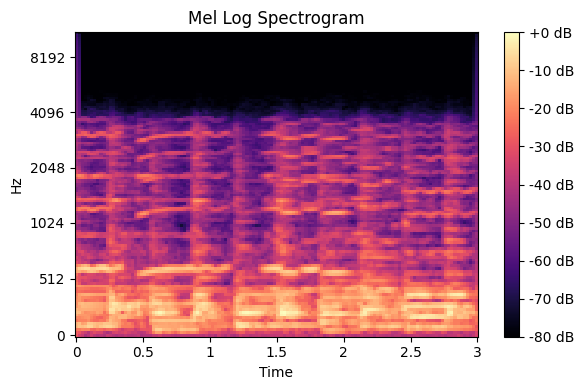

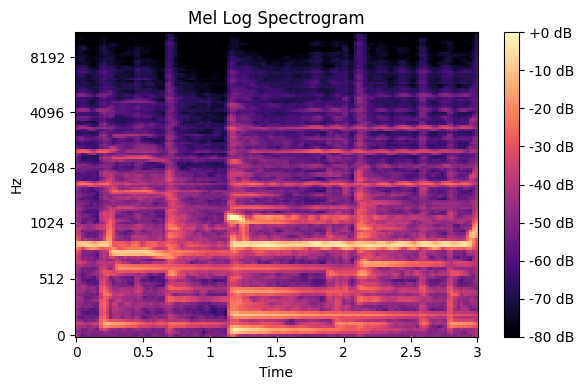

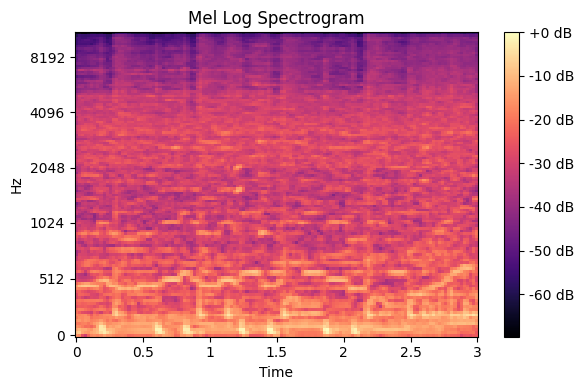

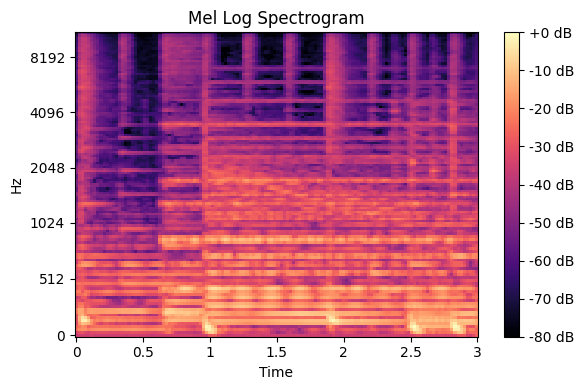

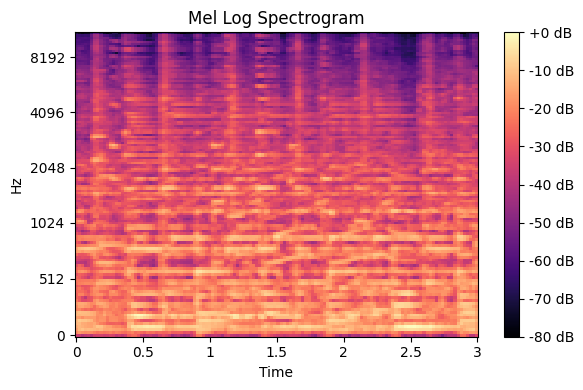

In [14]:
import os
os.makedirs("mel_images", exist_ok=True)

count = 0

for f in train_files:
    y = preprocess_audio(f)
    if y is None:
        continue

    mel_db = make_mel_log(y)
    save_mel_image(mel_db, f"mel_images/mel_{count}.png")

    count += 1
    if count == 5:
        break


In [15]:
unique_labels = sorted(set(labels))
print("Unique instrument classes:")
print(unique_labels)
print("Total classes:", len(unique_labels))

Unique instrument classes:
['cel', 'cla', 'flu', 'gac', 'gel', 'org', 'pia', 'sax', 'tru', 'vio', 'voi']
Total classes: 11


In [16]:
print("Total files:", len(files))
print("Total labels:", len(labels))

Total files: 6705
Total labels: 6705


In [17]:
binary_train_files = []
binary_train_labels = []

binary_test_files = []
binary_test_labels = []

for f, lab in zip(train_files, train_labels):
    if lab in ["pia", "dru"]:
        binary_train_files.append(f)
        binary_train_labels.append(lab)

for f, lab in zip(test_files, test_labels):
    if lab in ["pia", "dru"]:
        binary_test_files.append(f)
        binary_test_labels.append(lab)

print("Train (Piano+Drums):", len(binary_train_files))
print("Test (Piano+Drums):", len(binary_test_files))

Train (Piano+Drums): 577
Test (Piano+Drums): 144


In [18]:
def plot_waveform(y, label):
    plt.figure(figsize=(8,3))
    librosa.display.waveshow(y, sr=SR)
    plt.title(f"Waveform - {label}")
    plt.show()


Test Sample: 1
True Label: pia


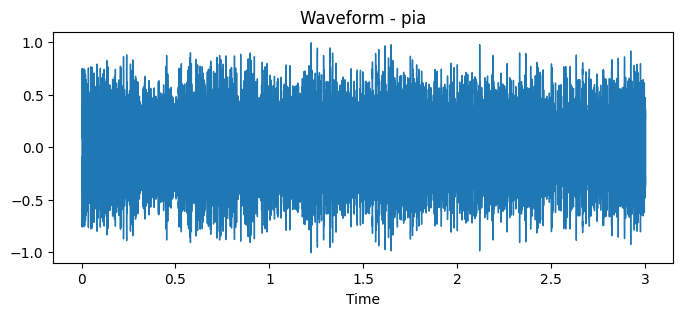

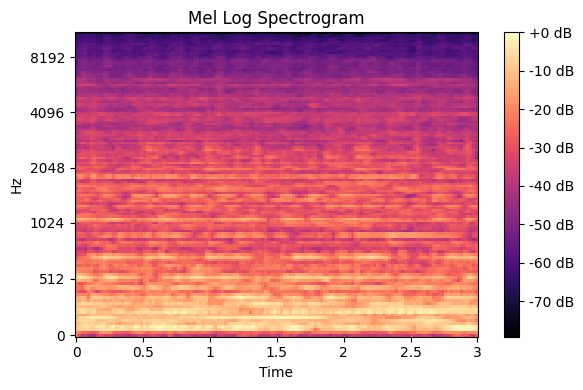


Test Sample: 2
True Label: pia


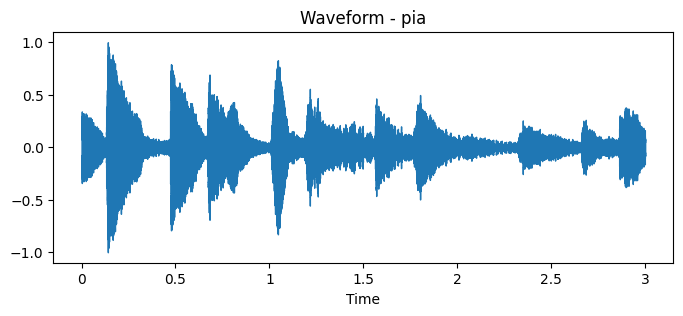

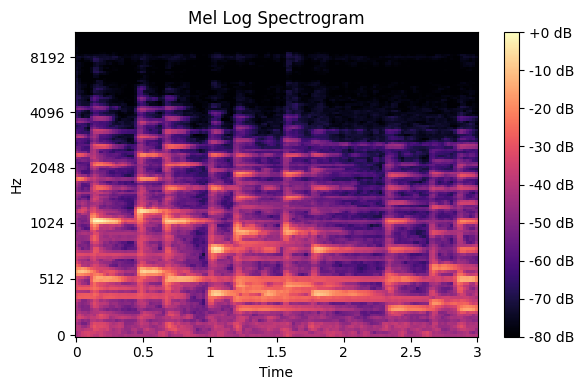


Test Sample: 3
True Label: pia


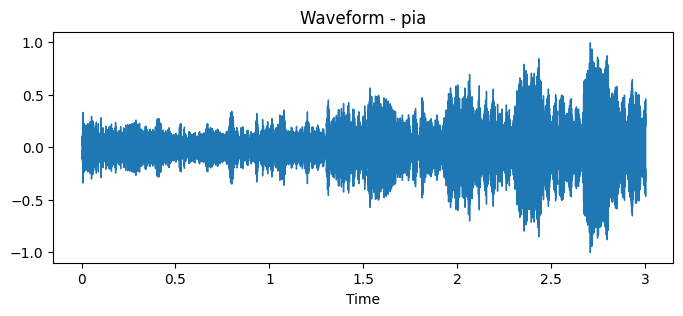

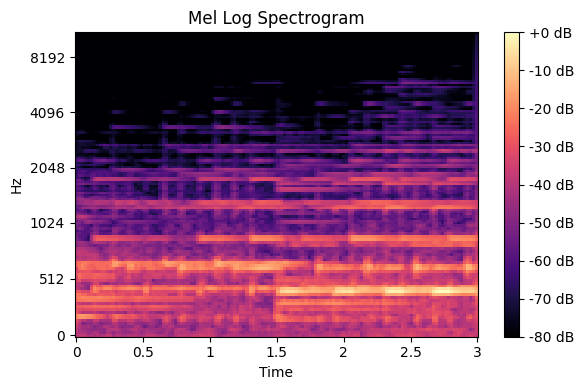


Test Sample: 4
True Label: pia


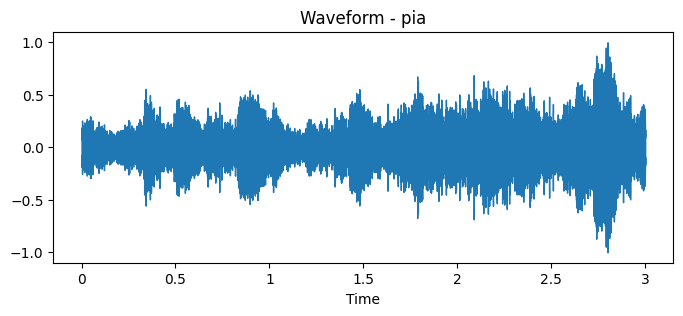

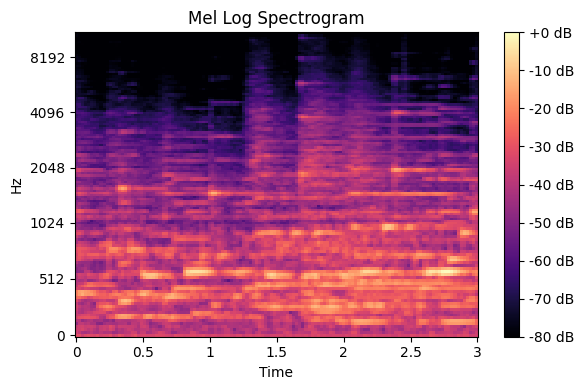


Test Sample: 5
True Label: pia


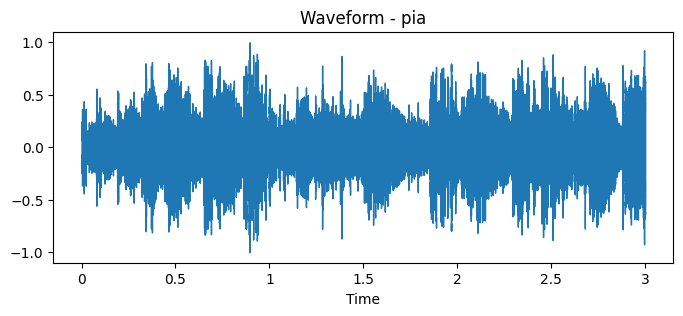

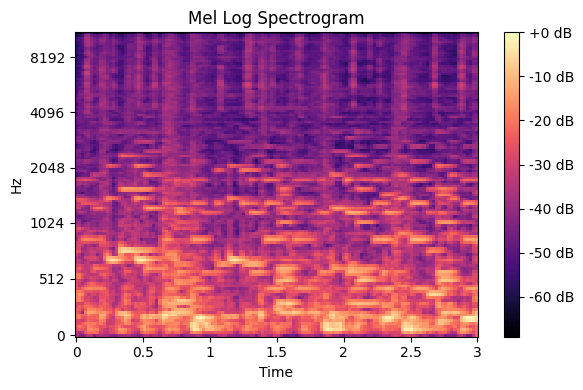

In [19]:
for i in range(5):
    file_path = binary_test_files[i]
    true_label = binary_test_labels[i]

    print("\nTest Sample:", i+1)
    print("True Label:", true_label)

    y = preprocess_audio(file_path)

    if y is None:
        print("Skipped silent file")
        continue

    plot_waveform(y, true_label)

    mel_db = make_mel_log(y)
    save_mel_image(mel_db, f"mel_images/test_{i}_{true_label}.png")

In [20]:
import numpy as np

def time_shift(y, shift_max=0.2):
    """
    shift_max = max % of total length to shift
    """
    shift = int(np.random.uniform(-shift_max, shift_max) * len(y))
    y_shifted = np.roll(y, shift)
    return y_shifted

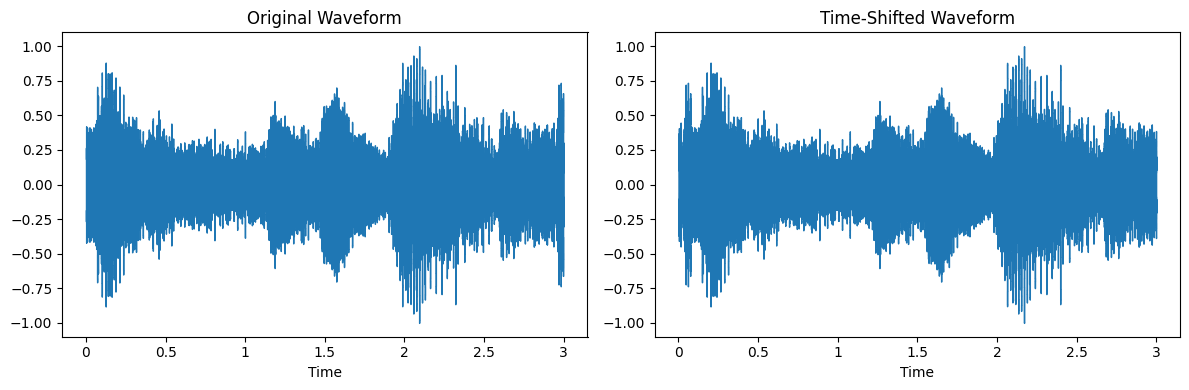

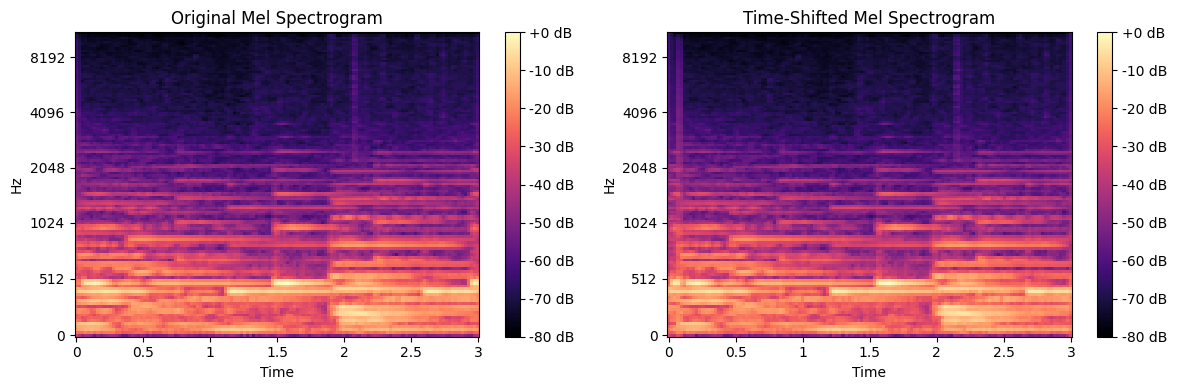

In [21]:
import matplotlib.pyplot as plt
import librosa.display

# Take one sample from binary train set
file_path = binary_train_files[0]
label = binary_train_labels[0]

y = preprocess_audio(file_path)

# Apply augmentation
y_shifted = time_shift(y)

# ---------- WAVEFORM COMPARISON ----------
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
librosa.display.waveshow(y, sr=SR)
plt.title("Original Waveform")

plt.subplot(1,2,2)
librosa.display.waveshow(y_shifted, sr=SR)
plt.title("Time-Shifted Waveform")

plt.tight_layout()
plt.show()


# ---------- MEL SPECTROGRAM COMPARISON ----------
mel_original = make_mel_log(y)
mel_shifted = make_mel_log(y_shifted)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
librosa.display.specshow(mel_original, sr=SR,
                         x_axis='time', y_axis='mel')
plt.title("Original Mel Spectrogram")
plt.colorbar(format="%+2.0f dB")

plt.subplot(1,2,2)
librosa.display.specshow(mel_shifted, sr=SR,
                         x_axis='time', y_axis='mel')
plt.title("Time-Shifted Mel Spectrogram")
plt.colorbar(format="%+2.0f dB")

plt.tight_layout()
plt.show()

In [22]:
from collections import Counter

print("Full Dataset Class Distribution:")
print(Counter(labels))

Full Dataset Class Distribution:
Counter({'voi': 778, 'gel': 760, 'pia': 721, 'org': 682, 'gac': 637, 'sax': 626, 'vio': 580, 'tru': 577, 'cla': 505, 'flu': 451, 'cel': 388})


In [23]:
print("Train Class Distribution:")
print(Counter(train_labels))

print("\nTest Class Distribution:")
print(Counter(test_labels))

Train Class Distribution:
Counter({'voi': 622, 'gel': 608, 'pia': 577, 'org': 546, 'gac': 510, 'sax': 501, 'vio': 464, 'tru': 461, 'cla': 404, 'flu': 361, 'cel': 310})

Test Class Distribution:
Counter({'voi': 156, 'gel': 152, 'pia': 144, 'org': 136, 'gac': 127, 'sax': 125, 'vio': 116, 'tru': 116, 'cla': 101, 'flu': 90, 'cel': 78})


In [24]:
print("Does drum exist in train?", "dru" in train_labels)
print("Does piano exist in train?", "pia" in train_labels)

print("Does drum exist in test?", "dru" in test_labels)
print("Does piano exist in test?", "pia" in test_labels)

Does drum exist in train? False
Does piano exist in train? True
Does drum exist in test? False
Does piano exist in test? True


In [25]:
print("\nSample 5 Train Files:")
for i in range(5):
    print(train_files[i], " → ", train_labels[i])


Sample 5 Train Files:
C:\Users\shaik\OneDrive\Desktop\insturment.ai\archive\IRMAS-TrainingData\vio\[vio][jaz_blu]2137__1.wav  →  vio
C:\Users\shaik\OneDrive\Desktop\insturment.ai\archive\IRMAS-TrainingData\flu\[flu][pop_roc]0424__1.wav  →  flu
C:\Users\shaik\OneDrive\Desktop\insturment.ai\archive\IRMAS-TrainingData\vio\[vio][pop_roc]2252__3.wav  →  vio
C:\Users\shaik\OneDrive\Desktop\insturment.ai\archive\IRMAS-TrainingData\org\[org][pop_roc]1131__3.wav  →  org
C:\Users\shaik\OneDrive\Desktop\insturment.ai\archive\IRMAS-TrainingData\gac\[gac][pop_roc]0605__2.wav  →  gac


In [26]:
from sklearn.model_selection import train_test_split

train_files_final, val_files, train_labels_final, val_labels = train_test_split(
    train_files,
    train_labels,
    test_size=0.20,
    stratify=train_labels,
    random_state=42
)

print("Final Train:", len(train_files_final))
print("Validation:", len(val_files))
print("Test:", len(test_files))

Final Train: 4291
Validation: 1073
Test: 1341


In [27]:
print("\nFinal Train Distribution:")
print(Counter(train_labels_final))

print("\nValidation Distribution:")
print(Counter(val_labels))

print("\nTest Distribution:")
print(Counter(test_labels))


Final Train Distribution:
Counter({'voi': 497, 'gel': 486, 'pia': 462, 'org': 437, 'gac': 408, 'sax': 401, 'vio': 371, 'tru': 369, 'cla': 323, 'flu': 289, 'cel': 248})

Validation Distribution:
Counter({'voi': 125, 'gel': 122, 'pia': 115, 'org': 109, 'gac': 102, 'sax': 100, 'vio': 93, 'tru': 92, 'cla': 81, 'flu': 72, 'cel': 62})

Test Distribution:
Counter({'voi': 156, 'gel': 152, 'pia': 144, 'org': 136, 'gac': 127, 'sax': 125, 'vio': 116, 'tru': 116, 'cla': 101, 'flu': 90, 'cel': 78})


In [28]:
import numpy as np
import librosa.display
import matplotlib.pyplot as plt

# Take one test file
file_path = binary_test_files[0]
true_label = binary_test_labels[0]

print("True Label:", true_label)

# Preprocess
y = preprocess_audio(file_path)

# Generate mel
mel_db = make_mel_log(y)

# Resize to fixed size (if needed)
mel_db = mel_db[:, :256]  # adjust if your model uses fixed width

# Add channel dimension
mel_input = np.expand_dims(mel_db, axis=-1)
mel_input = np.expand_dims(mel_input, axis=0)

True Label: pia


In [29]:
from tensorflow.keras import layers, models

model = models.Sequential([
    
    layers.Input(shape=(128,256,1)),   # input layer

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(11, activation='softmax')   # number of instrument classes
])

In [31]:
import os

DATASET_PATH = r"C:\Users\shaik\OneDrive\Desktop\insturment.ai\archive\IRMAS-TrainingData"

files = []
labels = []

for root, _, fs in os.walk(DATASET_PATH):
    for f in fs:
        if f.endswith(".wav"):
            files.append(os.path.join(root, f))
            labels.append(os.path.basename(root))

print("Total files:", len(files))
print("Sample:", files[0])

Total files: 6705
Sample: C:\Users\shaik\OneDrive\Desktop\insturment.ai\archive\IRMAS-TrainingData\cel\008__[cel][nod][cla]0058__1.wav


In [32]:
from sklearn.model_selection import train_test_split

train_files, test_files, train_labels, test_labels = train_test_split(
    files,
    labels,
    test_size=0.20,
    stratify=labels,
    random_state=42
)

print("Train samples:", len(train_files))
print("Test samples:", len(test_files))

Train samples: 5364
Test samples: 1341


In [34]:
MAX_LEN = 256   # fixed time dimension for CNN input

def fix_length(mel):
    if mel.shape[1] < MAX_LEN:
        pad = MAX_LEN - mel.shape[1]
        mel = np.pad(mel, ((0,0),(0,pad)))
    else:
        mel = mel[:, :MAX_LEN]
    return mel

In [35]:
import numpy as np

X_train = []
y_train = []

X_test = []
y_test = []

for f, lab in zip(train_files, train_labels):

    y = preprocess_audio(f)

    if y is None or len(y) == 0:
        continue

    mel = make_mel_log(y)
    mel = fix_length(mel)

    X_train.append(mel)
    y_train.append(lab)

for f, lab in zip(test_files, test_labels):

    y = preprocess_audio(f)

    if y is None or len(y) == 0:
        continue

    mel = make_mel_log(y)
    mel = fix_length(mel)

    X_test.append(mel)
    y_test.append(lab)

X_train = np.array(X_train)[..., None]
X_test  = np.array(X_test)[..., None]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (5364, 128, 256, 1)
X_test shape: (1341, 128, 256, 1)


In [36]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

print("y_train shape:", y_train.shape)

y_train shape: (5364, 11)


In [37]:
from tensorflow.keras import layers, models

model = models.Sequential([

    layers.Input(shape=(128,256,1)),

    layers.Conv2D(32,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(y_train.shape[1], activation='softmax')
])

In [38]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [39]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    verbose=1
)

callbacks = [checkpoint, reduce_lr]

In [40]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks
)

Epoch 1/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1006 - loss: 6.3283
Epoch 1: val_loss improved from None to 2.38153, saving model to best_model.keras
135/135 ━━━━━━━━━━━━━━━━━━━━ 330s 2s/step - accuracy: 0.1109 - loss: 3.3150 - val_accuracy: 0.1193 - val_loss: 2.3815 - learning_rate: 0.0010
Epoch 2/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1257 - loss: 2.3730
Epoch 2: val_loss did not improve from 2.38153
135/135 ━━━━━━━━━━━━━━━━━━━━ 326s 2s/step - accuracy: 0.1221 - loss: 2.3759 - val_accuracy: 0.1081 - val_loss: 2.3857 - learning_rate: 0.0010
Epoch 3/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1438 - loss: 2.3668
Epoch 3: val_loss improved from 2.38153 to 2.28239, saving model to best_model.keras
135/135 ━━━━━━━━━━━━━━━━━━━━ 324s 2s/step - accuracy: 0.1592 - loss: 2.3385 - val_accuracy: 0.2032 - val_loss: 2.2824 - learning_rate: 0.0010
Epoch 4/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2046 - loss: 2.2414
Epoch 4: val_loss im

In [41]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

42/42 ━━━━━━━━━━━━━━━━━━━━ 19s 448ms/step - accuracy: 0.3691 - loss: 1.9885
Test Accuracy: 0.3691275119781494
Test Loss: 1.988523006439209


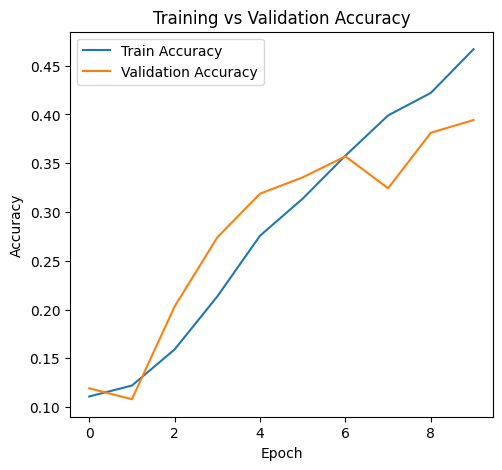

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

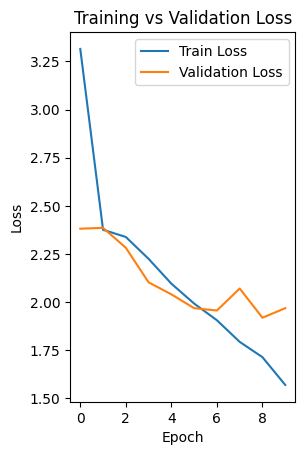

In [43]:
plt.subplot(1,2,2)

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [44]:
train_loss = history.history['loss'][-1]
val_loss = history.history['val_loss'][-1]

print("Final Train Loss:", train_loss)
print("Final Validation Loss:", val_loss)
print("Test Loss:", test_loss)

Final Train Loss: 1.5701866149902344
Final Validation Loss: 1.9685800075531006
Test Loss: 1.988523006439209


In [45]:
import numpy as np

y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

42/42 ━━━━━━━━━━━━━━━━━━━━ 20s 468ms/step


In [46]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true_classes,
    y_pred_classes,
    target_names=le.classes_
))

              precision    recall  f1-score   support

         cel       0.33      0.10      0.16        78
         cla       0.36      0.21      0.26       101
         flu       0.37      0.17      0.23        90
         gac       0.50      0.35      0.41       127
         gel       0.26      0.57      0.35       152
         org       0.47      0.39      0.43       136
         pia       0.50      0.42      0.46       144
         sax       0.26      0.31      0.28       125
         tru       0.51      0.56      0.53       116
         vio       0.38      0.22      0.28       116
         voi       0.37      0.48      0.42       156

    accuracy                           0.37      1341
   macro avg       0.39      0.34      0.35      1341
weighted avg       0.39      0.37      0.36      1341



In [47]:
from sklearn.metrics import precision_score, recall_score

precision_per_class = precision_score(
    y_true_classes,
    y_pred_classes,
    average=None
)

recall_per_class = recall_score(
    y_true_classes,
    y_pred_classes,
    average=None
)

for i, instrument in enumerate(le.classes_):
    print(instrument)
    print("Precision:", precision_per_class[i])
    print("Recall:", recall_per_class[i])
    print()

cel
Precision: 0.3333333333333333
Recall: 0.10256410256410256

cla
Precision: 0.3620689655172414
Recall: 0.2079207920792079

flu
Precision: 0.36585365853658536
Recall: 0.16666666666666666

gac
Precision: 0.5
Recall: 0.3543307086614173

gel
Precision: 0.25588235294117645
Recall: 0.5723684210526315

org
Precision: 0.4732142857142857
Recall: 0.3897058823529412

pia
Precision: 0.4959349593495935
Recall: 0.4236111111111111

sax
Precision: 0.2565789473684211
Recall: 0.312

tru
Precision: 0.5078125
Recall: 0.5603448275862069

vio
Precision: 0.38235294117647056
Recall: 0.22413793103448276

voi
Precision: 0.36585365853658536
Recall: 0.4807692307692308



In [48]:
print("Overall Accuracy:", test_accuracy)

print("\nPer-Instrument Metrics")

for i, inst in enumerate(le.classes_):

    print(inst,
          "| Precision:", round(precision_per_class[i],3),
          "| Recall:", round(recall_per_class[i],3))

Overall Accuracy: 0.3691275119781494

Per-Instrument Metrics
cel | Precision: 0.333 | Recall: 0.103
cla | Precision: 0.362 | Recall: 0.208
flu | Precision: 0.366 | Recall: 0.167
gac | Precision: 0.5 | Recall: 0.354
gel | Precision: 0.256 | Recall: 0.572
org | Precision: 0.473 | Recall: 0.39
pia | Precision: 0.496 | Recall: 0.424
sax | Precision: 0.257 | Recall: 0.312
tru | Precision: 0.508 | Recall: 0.56
vio | Precision: 0.382 | Recall: 0.224
voi | Precision: 0.366 | Recall: 0.481


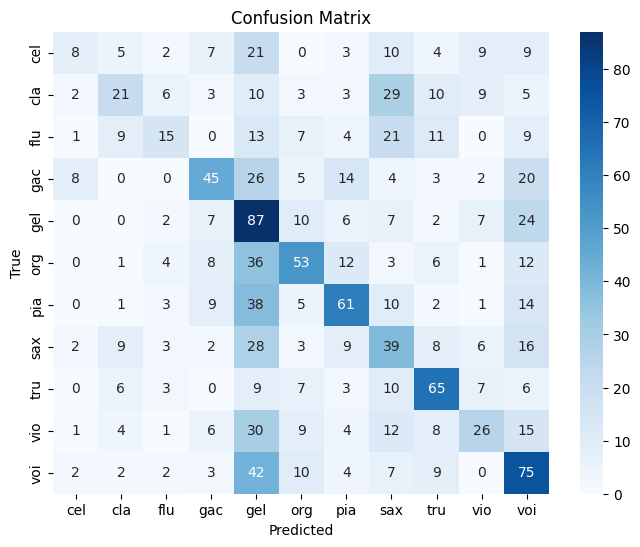

In [50]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(8,6))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [52]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()

y_train = mlb.fit_transform([[l] for l in train_labels])
y_test  = mlb.transform([[l] for l in test_labels])

print("y_train shape:", y_train.shape)

y_train shape: (5364, 11)


In [53]:
from tensorflow.keras import layers, models

model = models.Sequential([

    layers.Input(shape=(128,256,1)),

    layers.Conv2D(32,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(y_train.shape[1], activation='sigmoid')   # changed here
])

In [54]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [55]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 254s 2s/step - accuracy: 0.1121 - loss: 0.4602 - val_accuracy: 0.1594 - val_loss: 0.3114
Epoch 2/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 263s 2s/step - accuracy: 0.1701 - loss: 0.3110 - val_accuracy: 0.2227 - val_loss: 0.2901
Epoch 3/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 248s 2s/step - accuracy: 0.2291 - loss: 0.2926 - val_accuracy: 0.2787 - val_loss: 0.2741
Epoch 4/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 243s 2s/step - accuracy: 0.2459 - loss: 0.2864 - val_accuracy: 0.3038 - val_loss: 0.2702
Epoch 5/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 225s 2s/step - accuracy: 0.2766 - loss: 0.2800 - val_accuracy: 0.3262 - val_loss: 0.2672
Epoch 6/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 219s 2s/step - accuracy: 0.3025 - loss: 0.2743 - val_accuracy: 0.3299 - val_loss: 0.2635
Epoch 7/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 219s 2s/step - accuracy: 0.3172 - loss: 0.2688 - val_accuracy: 0.3709 - val_loss: 0.2574
Epoch 8/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 219s 2s/step - accuracy: 0.3305 - loss: 0.2623 - val_accu

In [56]:
import numpy as np

pred_probs = model.predict(X_test)

print("Predicted probabilities for first sample:")
print(pred_probs[0])

42/42 ━━━━━━━━━━━━━━━━━━━━ 20s 475ms/step
Predicted probabilities for first sample:
[0.05307212 0.1825719  0.0119877  0.02122517 0.00266637 0.00029125
 0.00790459 0.19337936 0.00314299 0.01981338 0.00061896]


In [60]:
print(pred_probs[0])

[0.05307212 0.1825719  0.0119877  0.02122517 0.00266637 0.00029125
 0.00790459 0.19337936 0.00314299 0.01981338 0.00061896]


In [78]:
threshold = 0.09
pred_labels = (pred_probs > threshold).astype(int)

In [79]:
instrument_names = mlb.classes_
for i in range(10):

    predicted = [
        instrument_names[j]
        for j,val in enumerate(pred_labels[i])
        if val == 1
    ]

    print("Sample", i)
    print("Predicted instruments:", predicted)

Sample 0
Predicted instruments: ['cla', 'sax']
Sample 1
Predicted instruments: ['cla', 'flu', 'pia', 'sax']
Sample 2
Predicted instruments: ['cla', 'flu', 'pia']
Sample 3
Predicted instruments: ['sax', 'tru']
Sample 4
Predicted instruments: ['flu', 'org', 'tru']
Sample 5
Predicted instruments: ['flu', 'tru']
Sample 6
Predicted instruments: ['gel', 'org', 'voi']
Sample 7
Predicted instruments: ['cel', 'cla', 'gel', 'sax', 'vio']
Sample 8
Predicted instruments: ['cla', 'flu', 'pia', 'sax', 'tru']
Sample 9
Predicted instruments: ['cel', 'gel', 'org']


In [59]:
for i in range(3):

    print("\nSample", i)

    for j, inst in enumerate(instrument_names):
        print(inst, ":", round(pred_probs[i][j],3))

    predicted = [
        instrument_names[j]
        for j,val in enumerate(pred_labels[i])
        if val == 1
    ]

    print("Predicted:", predicted)


Sample 0
cel : 0.053
cla : 0.183
flu : 0.012
gac : 0.021
gel : 0.003
org : 0.0
pia : 0.008
sax : 0.193
tru : 0.003
vio : 0.02
voi : 0.001
Predicted: []

Sample 1
cel : 0.062
cla : 0.116
flu : 0.151
gac : 0.004
gel : 0.052
org : 0.015
pia : 0.155
sax : 0.125
tru : 0.052
vio : 0.041
voi : 0.008
Predicted: []

Sample 2
cel : 0.013
cla : 0.175
flu : 0.094
gac : 0.0
gel : 0.008
org : 0.001
pia : 0.094
sax : 0.074
tru : 0.02
vio : 0.007
voi : 0.003
Predicted: []


In [80]:
from tensorflow.keras import layers, models

model = models.Sequential([

    layers.Input(shape=(128,256,1)),

    layers.Conv2D(32,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(y_train.shape[1], activation='sigmoid')   # changed
])

In [81]:
import tensorflow as tf

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

In [82]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 283s 2s/step - accuracy: 0.1039 - loss: 0.4532 - precision: 0.1065 - recall: 0.0131 - val_accuracy: 0.0895 - val_loss: 0.3062 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 219s 2s/step - accuracy: 0.1373 - loss: 0.3143 - precision: 0.1765 - recall: 6.9914e-04 - val_accuracy: 0.1640 - val_loss: 0.2919 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 224s 2s/step - accuracy: 0.2118 - loss: 0.2973 - precision: 0.3361 - recall: 0.0093 - val_accuracy: 0.3271 - val_loss: 0.2715 - val_precision: 0.6667 - val_recall: 0.0019
Epoch 4/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 281s 2s/step - accuracy: 0.2897 - loss: 0.2801 - precision: 0.4966 - recall: 0.0340 - val_accuracy: 0.3458 - val_loss: 0.2584 - val_precision: 0.7000 - val_recall: 0.0065
Epoch 5/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 278s 2s/step - accuracy: 0.3361 - loss: 0.2697 - precision: 0.4664 - recall: 0.0485 - val_accura

In [83]:
import numpy as np

val_samples = X_train[:5]

pred_probs = model.predict(val_samples)

print("Prediction Probabilities:")
print(pred_probs)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step
Prediction Probabilities:
[[0.04467919 0.01039689 0.00650273 0.14729321 0.05602077 0.00279984
  0.02403431 0.03368212 0.00669197 0.04402564 0.48277798]
 [0.00465049 0.13712958 0.5321561  0.0038246  0.00786966 0.00160399
  0.06009056 0.08541019 0.00440533 0.07434577 0.00821934]
 [0.01186178 0.01571189 0.01234398 0.02752516 0.55802166 0.06187856
  0.01867442 0.02998438 0.01359892 0.04706182 0.19826916]
 [0.0209872  0.01226487 0.02307598 0.12417792 0.10651008 0.39271942
  0.07404693 0.01540028 0.01399775 0.03248972 0.17600082]
 [0.08106193 0.0153605  0.01352403 0.4263418  0.13200924 0.07976612
  0.01086755 0.02665471 0.0214774  0.05682508 0.2787509 ]]


In [84]:
import numpy as np

val_samples = X_train[:5]

pred_probs = model.predict(val_samples)

print("Prediction Probabilities:")
print(pred_probs)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
Prediction Probabilities:
[[0.04467919 0.01039689 0.00650273 0.14729321 0.05602077 0.00279984
  0.02403431 0.03368212 0.00669197 0.04402564 0.48277798]
 [0.00465049 0.13712958 0.5321561  0.0038246  0.00786966 0.00160399
  0.06009056 0.08541019 0.00440533 0.07434577 0.00821934]
 [0.01186178 0.01571189 0.01234398 0.02752516 0.55802166 0.06187856
  0.01867442 0.02998438 0.01359892 0.04706182 0.19826916]
 [0.0209872  0.01226487 0.02307598 0.12417792 0.10651008 0.39271942
  0.07404693 0.01540028 0.01399775 0.03248972 0.17600082]
 [0.08106193 0.0153605  0.01352403 0.4263418  0.13200924 0.07976612
  0.01086755 0.02665471 0.0214774  0.05682508 0.2787509 ]]


In [85]:
instrument_names = le.classes_

for i in range(len(pred_labels)):

    predicted = [
        instrument_names[j]
        for j,val in enumerate(pred_labels[i])
        if val == 1
    ]

    print("\nSample", i)
    print("Predicted Instruments:", predicted)


Sample 0
Predicted Instruments: [np.str_('cla'), np.str_('sax')]

Sample 1
Predicted Instruments: [np.str_('cla'), np.str_('flu'), np.str_('pia'), np.str_('sax')]

Sample 2
Predicted Instruments: [np.str_('cla'), np.str_('flu'), np.str_('pia')]

Sample 3
Predicted Instruments: [np.str_('sax'), np.str_('tru')]

Sample 4
Predicted Instruments: [np.str_('flu'), np.str_('org'), np.str_('tru')]

Sample 5
Predicted Instruments: [np.str_('flu'), np.str_('tru')]

Sample 6
Predicted Instruments: [np.str_('gel'), np.str_('org'), np.str_('voi')]

Sample 7
Predicted Instruments: [np.str_('cel'), np.str_('cla'), np.str_('gel'), np.str_('sax'), np.str_('vio')]

Sample 8
Predicted Instruments: [np.str_('cla'), np.str_('flu'), np.str_('pia'), np.str_('sax'), np.str_('tru')]

Sample 9
Predicted Instruments: [np.str_('cel'), np.str_('gel'), np.str_('org')]

Sample 10
Predicted Instruments: [np.str_('sax'), np.str_('voi')]

Sample 11
Predicted Instruments: [np.str_('gac'), np.str_('org')]

Sample 12
Pre

In [86]:
from sklearn.metrics import f1_score

y_pred = model.predict(X_test)

y_pred_binary = (y_pred > 0.5).astype(int)

f1 = f1_score(y_test, y_pred_binary, average='macro')

print("F1 Score:", f1)

42/42 ━━━━━━━━━━━━━━━━━━━━ 21s 483ms/step
F1 Score: 0.21641442213483328


In [97]:
import numpy as np

y_pred_probs = model.predict(X_test)

y_pred_class = np.argmax(y_pred_probs, axis=1)
y_true_class = np.argmax(y_test, axis=1)

42/42 ━━━━━━━━━━━━━━━━━━━━ 20s 470ms/step


In [88]:
threshold = 0.5

y_pred = (y_pred_probs > threshold).astype(int)

In [89]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test.argmax(axis=1), y_pred_probs.argmax(axis=1))

print("Overall Accuracy:", accuracy)

Overall Accuracy: 0.41387024608501116


In [90]:
from sklearn.metrics import classification_report

y_true = np.argmax(y_test, axis=1)
y_pred_class = np.argmax(y_pred_probs, axis=1)

print(classification_report(
    y_true,
    y_pred_class,
    target_names=le.classes_
))

              precision    recall  f1-score   support

         cel       0.43      0.15      0.23        78
         cla       0.36      0.43      0.39       101
         flu       0.37      0.28      0.32        90
         gac       0.43      0.57      0.49       127
         gel       0.36      0.52      0.42       152
         org       0.54      0.48      0.51       136
         pia       0.39      0.60      0.47       144
         sax       0.35      0.07      0.12       125
         tru       0.56      0.38      0.45       116
         vio       0.40      0.30      0.34       116
         voi       0.42      0.53      0.47       156

    accuracy                           0.41      1341
   macro avg       0.42      0.39      0.38      1341
weighted avg       0.42      0.41      0.40      1341



In [91]:
from sklearn.metrics import recall_score

recall_scores = recall_score(y_true, y_pred_class, average=None)

weakest_class_index = np.argmin(recall_scores)

weakest_class = le.classes_[weakest_class_index]

print("Weakest Class:", weakest_class)
print("Recall:", recall_scores[weakest_class_index])

Weakest Class: sax
Recall: 0.072


In [92]:
errors = np.where(y_true != y_pred_class)[0]

print("Total Errors:", len(errors))

Total Errors: 786


In [93]:
for i in errors[:5]:

    print("\nSample", i)
    print("True:", le.classes_[y_true[i]])
    print("Predicted:", le.classes_[y_pred_class[i]])


Sample 1
True: sax
Predicted: pia

Sample 2
True: flu
Predicted: cla

Sample 3
True: cla
Predicted: gel

Sample 4
True: flu
Predicted: org

Sample 5
True: flu
Predicted: tru


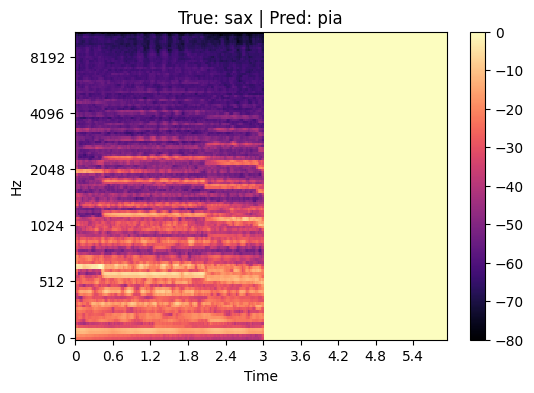

In [94]:
import librosa.display
import matplotlib.pyplot as plt

i = errors[0]

plt.figure(figsize=(6,4))

librosa.display.specshow(
    X_test[i].squeeze(),
    x_axis='time',
    y_axis='mel'
)

plt.title(f"True: {le.classes_[y_true[i]]} | Pred: {le.classes_[y_pred_class[i]]}")
plt.colorbar()
plt.show()

In [98]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

accuracy = accuracy_score(y_true_class, y_pred_class)

precision = precision_score(y_true_class, y_pred_class, average=None)
recall = recall_score(y_true_class, y_pred_class, average=None)
f1 = f1_score(y_true_class, y_pred_class, average=None)

In [99]:
weakest_index = np.argmin(recall)
weakest_class = le.classes_[weakest_index]
weakest_recall = recall[weakest_index]

In [100]:
errors = np.where(y_true_class != y_pred_class)[0]

In [101]:
print("\n=============== MODEL REPORT ================\n")

print("Overall Accuracy:", round(accuracy,3))

print("\nPer Instrument Metrics")

for i, inst in enumerate(le.classes_):
    print(f"{inst} -> Precision: {precision[i]:.3f} | Recall: {recall[i]:.3f} | F1: {f1[i]:.3f}")

print("\nWeakest Class:", weakest_class)
print("Recall Score:", round(weakest_recall,3))

print("\nTotal Misclassified Samples:", len(errors))

print("\nExample Errors:")

for i in errors[:5]:
    print("True:", le.classes_[y_true_class[i]],
          "| Predicted:", le.classes_[y_pred_class[i]])


=============== MODEL REPORT ================

Overall Accuracy: 0.414

Per Instrument Metrics
cel -> Precision: 0.429 | Recall: 0.154 | F1: 0.226
cla -> Precision: 0.358 | Recall: 0.426 | F1: 0.389
flu -> Precision: 0.368 | Recall: 0.278 | F1: 0.316
gac -> Precision: 0.432 | Recall: 0.575 | F1: 0.493
gel -> Precision: 0.356 | Recall: 0.520 | F1: 0.422
org -> Precision: 0.537 | Recall: 0.478 | F1: 0.506
pia -> Precision: 0.390 | Recall: 0.604 | F1: 0.474
sax -> Precision: 0.346 | Recall: 0.072 | F1: 0.119
tru -> Precision: 0.557 | Recall: 0.379 | F1: 0.451
vio -> Precision: 0.398 | Recall: 0.302 | F1: 0.343
voi -> Precision: 0.421 | Recall: 0.532 | F1: 0.470

Weakest Class: sax
Recall Score: 0.072

Total Misclassified Samples: 786

Example Errors:
True: sax | Predicted: pia
True: flu | Predicted: cla
True: cla | Predicted: gel
True: flu | Predicted: org
True: flu | Predicted: tru
